In [ ]:
import torch

print(f"torch version: {torch.__version__}")
print(f"torch cuda version: {torch.version.cuda}")
device = torch.device(torch.cuda.current_device() if torch.cuda.is_available() else "cpu")
print(f"torch device: {device}")
print(f"device name: {torch.cuda.get_device_name(device) if torch.cuda.is_available() else 'cpu'}")

torch version: 2.6.0+cu126
torch cuda version: 12.6
torch device: cuda:0
device name: NVIDIA GeForce RTX 4090 Laptop GPU


In [ ]:
from peft import LoraConfig
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
)
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj"],
)


sa_merge_model = AutoModelForCausalLM.from_pretrained(
    "../mistral-7b-lora-SA",
    quantization_config=bnb_config,
    torch_dtype=torch.bfloat16,
    device_map="auto",
)

sa_tokenizer = AutoTokenizer.from_pretrained("../mistral-7b-lora-SA")
sa_tokenizer.pad_token = sa_tokenizer.eos_token

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

In [ ]:
import re

import tqdm
from mistral_data import MissionType, MistralData

FuncFindAnswer = lambda text: re.search(r"Answer: (.*)", text).group(1).strip() if re.search(r"Answer: (.*)", text) else "None"

def predict(Model, Tokenizer, MistralData: MistralData) -> list:
    y_pred = []
    test_data = MistralData.test_dataset["train"]
    # logger.info("Predicting...")
    for i in tqdm.tqdm(range(len(test_data))):
        input_text = test_data["input"][i]
        instruction_text = test_data["instruction"][i]
        format_input = f"<s>[INST] {instruction_text} {input_text} [/INST]"
        input_ids = Tokenizer(format_input, return_tensors="pt").input_ids.to(
            device
        )
        attention_mask = Tokenizer(
            format_input, return_tensors="pt"
        ).attention_mask.to(device)
        Model.gradient_checkpointing_enable()
        Model.generation_config.pad_token_id = Tokenizer.pad_token_id
        output = Model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            num_return_sequences=1,
        )
        Model.gradient_checkpointing_enable()
        # print(sequences[0]["generated_text"])
        output_text = Tokenizer.decode(output[0], skip_special_tokens=True)
        # print(f"Output: {output_text}")
        a = FuncFindAnswer(output_text)
        # print(f"Answer: {a}")
        y_pred.append(a)
    return y_pred

y_pred = predict(sa_merge_model, sa_tokenizer, MistralData(MissionType.SA))
y_test = MistralData(MissionType.SA).df_test["y_true"].tolist()

print(f"y_test: {y_test}")
print(f"y_pred: {y_pred}")

2025-04-19 21:04:14 - INFO - Creating jsonl for Index(['job_id', 'job_title', 'job_ad_details', 'nation_short_desc',
       'salary_additional_text', 'y_true'],
      dtype='object') rows


MISC_DATA_PATH: ..\..\MISC
JOB_DATA_PATH: ..\..\MISC\job_data_files


Creating jsonl: 100%|██████████| 2267/2267 [00:00<00:00, 48862.46it/s]


Generating train split: 0 examples [00:00, ? examples/s]

2025-04-19 21:04:15 - INFO - Creating jsonl for Index(['job_id', 'job_title', 'job_ad_details', 'nation_short_desc',
       'salary_additional_text', 'y_true'],
      dtype='object') rows
Creating jsonl: 100%|██████████| 567/567 [00:00<00:00, 53654.24it/s]


...

100%|██████████| 567/567 [13:22<00:00,  1.42s/it]
2025-04-19 21:17:38 - INFO - Creating jsonl for Index(['job_id', 'job_title', 'job_ad_details', 'nation_short_desc',
       'salary_additional_text', 'y_true'],
      dtype='object') rows
Creating jsonl: 100%|██████████| 2267/2267 [00:00<00:00, 41445.40it/s]


Generating train split: 0 examples [00:00, ? examples/s]

2025-04-19 21:17:39 - INFO - Creating jsonl for Index(['job_id', 'job_title', 'job_ad_details', 'nation_short_desc',
       'salary_additional_text', 'y_true'],
      dtype='object') rows
Creating jsonl: 100%|██████████| 567/567 [00:00<00:00, 38665.04it/s]


Generating train split: 0 examples [00:00, ? examples/s]

y_test: ['1500-1800-MYR-MONTHLY', '60-60-HKD-HOURLY', '0-0-None-None', '0-0-None-None', '0-0-None-None', '21-21-NZD-HOURLY', '0-0-None-None', '0-0-None-None', '32-32-AUD-HOURLY', '2000-3000-MYR-MONTHLY', '3000-4000-MYR-MONTHLY', '0-0-None-None', '0-0-None-None', '80-90-HKD-HOURLY', '142642-156491-AUD-ANNUAL', '0-0-None-None', '29-29-AUD-HOURLY', '1500-2500-MYR-MONTHLY', '66028-68086-AUD-ANNUAL', '0-0-None-None', '3000-4000-SGD-MONTHLY', '0-0-None-None', '0-0-None-None', '73-85-HKD-HOURLY', '5000-8000-MYR-MONTHLY', '30-30-NZD-HOURLY', '0-0-None-None', '500-1250-SGD-WEEKLY', '1500-1500-MYR-MONTHLY', '750-1125-SGD-WEEKLY', '0-0-None-None', '0-0-None-None', '0-0-None-None', '1500-1500-MYR-MONTHLY', '2000-2500-SGD-MONTHLY', '58008-58008-AUD-ANNUAL', '23-29-NZD-HOURLY', '3000-6000-MYR-MONTHLY', '31-31-NZD-HOURLY', '100-100-HKD-HOURLY', '500-667-PHP-DAILY', '107-150-SGD-DAILY', '1500-1500-MYR-MONTHLY', '20-25-AUD-HOURLY', '0-0-None-None', '0-0-None-None', '2700-3000-SGD-MONTHLY', '0-0-None-No

In [ ]:
import pandas as pd

df = pd.DataFrame({"y_true": y_test, "y_pred": y_pred})
df.to_csv("SA_Mistral_7B_Lora.csv", index=False)
df.head()

,y_true,y_pred
0,1500-1800-MYR-MONTHLY,1500-1800-MYR-MONTHLY
1,60-60-HKD-HOURLY,40-40-HKD-HOURLY
2,0-0-None-None,0-0-None-None
3,0-0-None-None,0-0-None-None
4,0-0-None-None,0-0-None-None


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: \t {accuracy:.8f}")
# Calculate precision

precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
print(f"Precision: \t {precision:.8f}")

# Calculate recall
recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)

print(f"Recall: \t {recall:.8f}")

# Calculate F1 score
f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)
print(f"F1 Score: \t {f1:.8f}")

# # Generate classification report
# report = classification_report(y_test, y_pred, zero_division=0)
# print(f"Classification Report: \n{report}")

Accuracy: 	 0.83597884
Precision: 	 0.83602238
Recall: 	 0.83597884
F1 Score: 	 0.83304905


In [ ]:
import numpy as np

print(f"df: {df.shape}")

list_yt = np.zeros((df.shape[0], 4), dtype=object)
print(f"list_yt: {list_yt.shape}")
list_yp = np.zeros((df.shape[0], 4), dtype=object)
print(f"list_yp: {list_yp.shape}")
list_yp.fill("None")


for i, row in df.iterrows():
    list_yt[i] = row["y_true"].split("-")
    t = row["y_pred"].split("-")
    # print(f"t: {t}")
    if t[-1] == '':
        t[-1] = "None"
    list_yp[i] = t

list_yt_time = list_yt[:, 3].astype(str)
list_yt_currency = list_yt[:, 2].astype(str)
list_yt_amount = list_yt[:, [0, 1]].astype(float)
list_yp_time = list_yp[:, 3].astype(str)
list_yp_currency = list_yp[:, 2].astype(str)
list_yp_amount = list_yp[:, [0, 1]].astype(float)

def report(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    report = classification_report(y_true, y_pred, zero_division=0)
    print(f"Accuracy: \t {accuracy:.8f}")
    print(f"Precision: \t {precision:.8f}")
    print(f"Recall: \t {recall:.8f}")
    print(f"F1 Score: \t {f1:.8f}")
    print(f"Classification Report: \n{report}")

df: (567, 2)
list_yt: (567, 4)
list_yp: (567, 4)


In [ ]:
report(list_yt_currency, list_yp_currency)

Accuracy: 	 0.98236332
Precision: 	 0.98201567
Recall: 	 0.98236332
F1 Score: 	 0.98204730
Classification Report: 
              precision    recall  f1-score   support

         AUD       1.00      1.00      1.00        72
         HKD       1.00      1.00      1.00        54
         IDR       1.00      1.00      1.00         1
         MYR       1.00      0.98      0.99        58
         NZD       0.90      0.82      0.86        34
        None       0.98      0.99      0.98       238
         PHP       1.00      1.00      1.00        32
         SGD       0.98      1.00      0.99        53
         THB       1.00      1.00      1.00        25

    accuracy                           0.98       567
   macro avg       0.98      0.98      0.98       567
weighted avg       0.98      0.98      0.98       567



In [ ]:
report(list_yt_time, list_yp_time)

Accuracy: 	 0.88888889
Precision: 	 0.91728679
Recall: 	 0.88888889
F1 Score: 	 0.90039439
Classification Report: 
              precision    recall  f1-score   support

          AN       0.00      0.00      0.00         0
        ANNU       0.00      0.00      0.00         0
      ANNUAL       0.00      0.00      0.00        26
       DAILY       1.00      1.00      1.00        14
      HOURLY       0.98      0.95      0.96       130
         MON       0.00      0.00      0.00         0
       MONTH       0.00      0.00      0.00         0
     MONTHLY       1.00      0.83      0.91       138
        None       0.93      0.99      0.96       238
        WEEK       0.00      0.00      0.00         0
      WEEKLY       1.00      0.81      0.89        21

    accuracy                           0.89       567
   macro avg       0.45      0.42      0.43       567
weighted avg       0.92      0.89      0.90       567



rel_err: [[0.         0.        ]
 [0.33333333 0.33333333]
 [0.         0.        ]
 ...
 [0.         0.        ]
 [0.         0.        ]
 [0.         0.        ]]


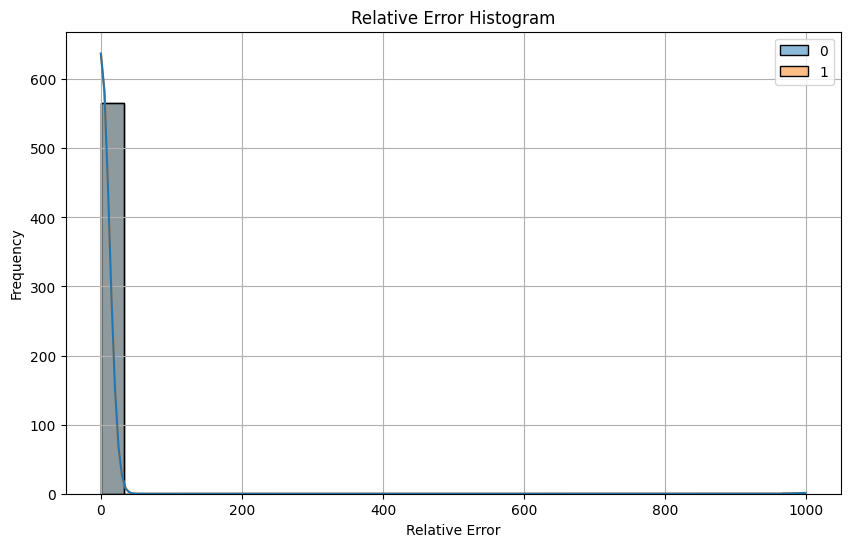

In [ ]:
# Relative Error
def relative_error(y_true: np.ndarray, y_pred: np.ndarray) -> np.ndarray:
    result = np.zeros(y_true.shape, dtype=float)
    for i in range(y_true.shape[0]):
        if y_true[i][0] == 0 and y_true[i][1] == 0:
            result[i] = 0
        else:
            result[i] = np.abs((y_true[i][0] - y_pred[i][0]) / y_true[i][0])
    return result

rel_err = relative_error(list_yt_amount, list_yp_amount)


print(f"rel_err: {rel_err}")


import seaborn as sns
from matplotlib import pyplot as plt


def plot_histogram(data, title, xlabel, ylabel):
    plt.figure(figsize=(10, 6))
    sns.histplot(data, bins=30, kde=True)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid()
    plt.show()


plot_histogram(rel_err, "Relative Error Histogram", "Relative Error", "Frequency")